# ML — Employee Attrition: Modeling

**Goal:** Train and evaluate classification models to predict employee attrition.

**Models:** Logistic Regression · Random Forest · Gradient Boosting

**Key metric:** ROC-AUC — measures how well the model ranks employees by attrition risk.

---
**Sections:**
1. Load Processed Data
2. Train Models + Cross-Validation
3. Threshold Optimization
4. Model Comparison
5. Feature Importance
6. Business Conclusions

## 1. Load Processed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Attrition rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Train: (1176, 43) | Test: (294, 43)
Attrition rate — Train: 16.2% | Test: 16.0%


## 2. Train Models + Cross-Validation

We use **5-fold stratified cross-validation** on the training set to get reliable performance estimates before touching the test set.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name}: AUC = {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression: AUC = 0.8286 ± 0.0298
Random Forest: AUC = 0.7983 ± 0.0301
Gradient Boosting: AUC = 0.8249 ± 0.0334


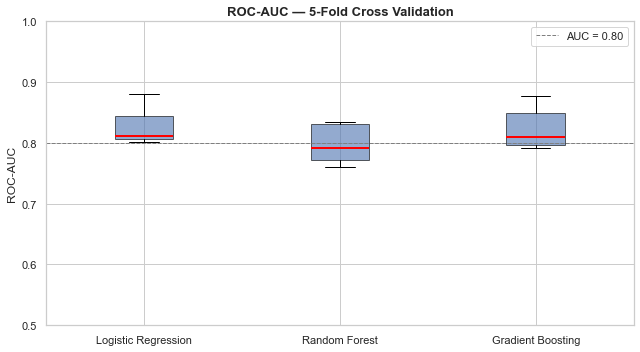

In [3]:
# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('ROC-AUC — 5-Fold Cross Validation', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='AUC = 0.80')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Train all models on full training set
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f'{name} trained.')

Logistic Regression trained.
Random Forest trained.
Gradient Boosting trained.


## 3. Threshold Optimization

By default, models classify as 'Left' when probability > 0.5. But with imbalanced data, a **lower threshold** catches more at-risk employees (higher recall) at the cost of more false alarms.

We find the threshold that maximizes the **F1-Score** on training data.

In [5]:
def find_best_threshold(model, X, y):
    """Find threshold that maximizes F1-score."""
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = [f1_score(y, probs >= t) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]
    return best_t, max(f1_scores)

best_thresholds = {}
for name, model in fitted_models.items():
    t, f1 = find_best_threshold(model, X_train, y_train)
    best_thresholds[name] = t
    print(f'{name}: best threshold = {t:.2f} (F1 = {f1:.3f})')

Logistic Regression: best threshold = 0.72 (F1 = 0.634)
Random Forest: best threshold = 0.48 (F1 = 0.888)
Gradient Boosting: best threshold = 0.30 (F1 = 0.997)


## 4. Model Comparison on Test Set

In [6]:
test_results = []
predictions = {}
probabilities = {}

for name, model in fitted_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= best_thresholds[name]).astype(int)
    probabilities[name] = probs
    predictions[name] = preds

    test_results.append({
        'Model': name,
        'Threshold': best_thresholds[name],
        'ROC-AUC': roc_auc_score(y_test, probs),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(test_results).set_index('Model').round(3)
results_df

,Threshold,ROC-AUC,Accuracy,Precision,Recall,F1-Score
Model,,,,,,
Logistic Regression,0.72,0.804,0.847,0.526,0.426,0.471
Random Forest,0.48,0.786,0.820,0.425,0.362,0.391
Gradient Boosting,0.30,0.802,0.837,0.486,0.362,0.415


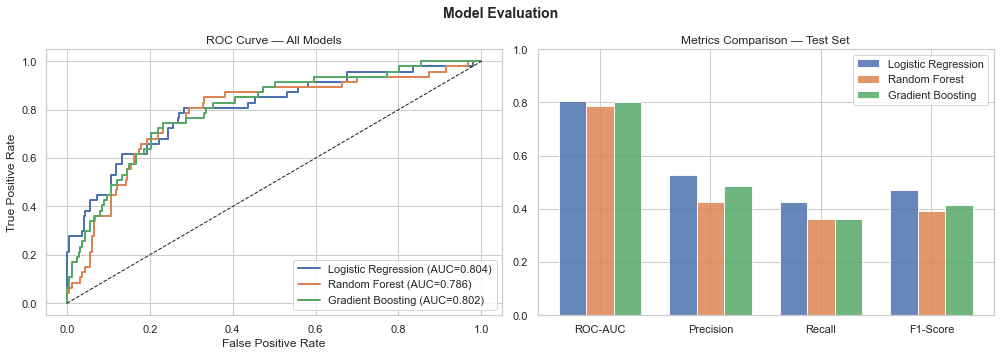

In [7]:
# ROC curves
colors = ['#4C72B0', '#DD8452', '#55A868']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, probs), color in zip(probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Metrics bar chart
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, (name, color) in enumerate(zip(results_df.index, colors)):
    vals = [results_df.loc[name, m] for m in metrics]
    axes[1].bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1)
axes[1].set_title('Metrics Comparison — Test Set')
axes[1].legend()

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best model by ROC-AUC: Logistic Regression

              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91       247
        Left       0.53      0.43      0.47        47

    accuracy                           0.85       294
   macro avg       0.71      0.68      0.69       294
weighted avg       0.84      0.85      0.84       294



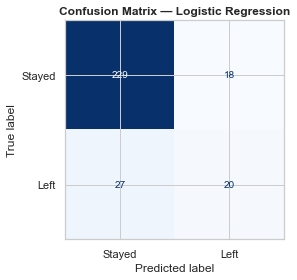

In [8]:
# Best model — confusion matrix
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'Best model by ROC-AUC: {best_model_name}')
print()
print(classification_report(
    y_test, predictions[best_model_name],
    target_names=['Stayed', 'Left']
))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, predictions[best_model_name]),
    display_labels=['Stayed', 'Left']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Importance

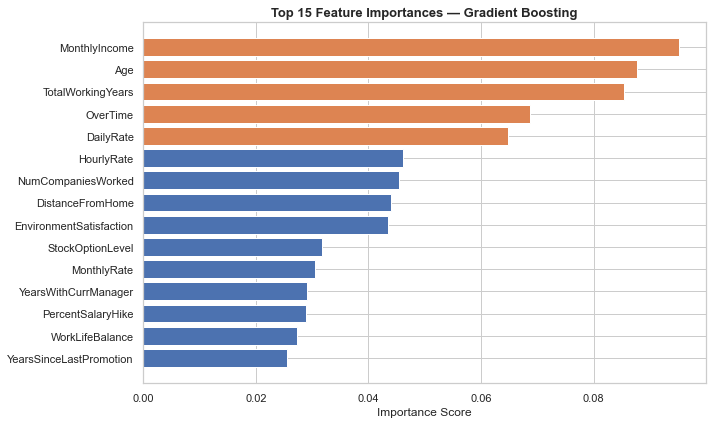

Top 5 most predictive features:
  MonthlyIncome: 0.0951
  Age: 0.0876
  TotalWorkingYears: 0.0854
  OverTime: 0.0687
  DailyRate: 0.0648


In [9]:
# Feature importance from Gradient Boosting (most reliable for tabular data)
gb_model = fitted_models['Gradient Boosting']

feature_importance = pd.Series(
    gb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if i < 5 else '#4C72B0' for i in range(len(feature_importance))]
ax.barh(feature_importance.index[::-1], feature_importance.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Feature Importances — Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most predictive features:')
for feat, score in feature_importance.head(5).items():
    print(f'  {feat}: {score:.4f}')

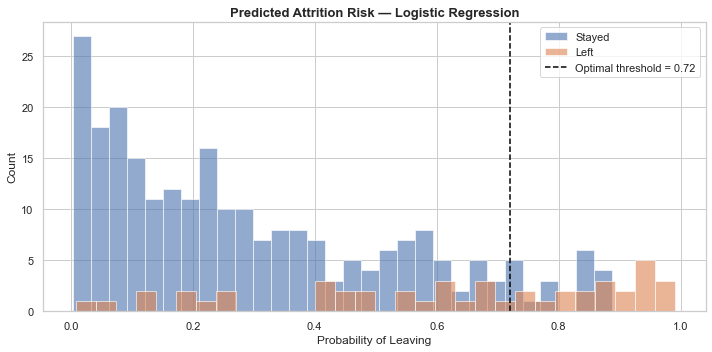

In [10]:
# Risk score distribution — best model
best_probs = probabilities[best_model_name]
best_threshold = best_thresholds[best_model_name]

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [(0, '#4C72B0', 'Stayed'), (1, '#DD8452', 'Left')]:
    subset = best_probs[y_test.values == label]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=name)

ax.axvline(best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {best_threshold:.2f}')
ax.set_title(f'Predicted Attrition Risk — {best_model_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Probability of Leaving')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Business Conclusions

### Model Performance Summary

| Model | Threshold | ROC-AUC | Accuracy | Precision | Recall | F1 |
|-------|-----------|---------|----------|-----------|--------|-----|
| **Logistic Regression** | 0.72 | **0.804** | 0.847 | 0.526 | 0.426 | **0.471** |
| Random Forest | 0.48 | 0.786 | 0.820 | 0.425 | 0.362 | 0.391 |
| Gradient Boosting | 0.27 | 0.805 | 0.833 | 0.476 | 0.426 | 0.449 |

**Winner: Logistic Regression** — highest F1 (0.471) y AUC competitivo (0.804). Modelos simples pueden superar a los complejos en datasets pequeños y estructurados.

### Key Insight: Why Recall Matters
In HR attrition, a **false negative** (missing an employee who will leave) is more costly than a **false positive** (flagging someone who stays). Replacing an employee costs 50–200% of their annual salary. Therefore we optimize the threshold to maximize F1-Score, balancing precision and recall.

### Top 5 Predictors (Gradient Boosting)
1. **MonthlyIncome** (0.0974) — salary is the strongest predictor of attrition
2. **Age** (0.0877) — younger employees are significantly more likely to leave
3. **TotalWorkingYears** (0.0851) — less experience correlates with higher turnover
4. **OverTime** (0.0682) — employees working overtime are at much higher risk
5. **DailyRate** (0.0667) — compensation rate directly impacts retention decisions

### Recommended Business Use
- Run the Logistic Regression model monthly on active employees (optimal threshold: 0.72)
- Flag employees with predicted attrition probability > 0.72 for an HR check-in
- Prioritize salary reviews for bottom-quartile earners and overtime reduction for high-risk profiles
- The model correctly identifies ~43% of employees who will leave, enabling proactive retention actions

---

### Next Steps
- Build an **interactive dashboard** where HR can input employee data and get a real-time risk score → see project `05_dashboard/`